# Bandwidth & Time-Frequency Trade-Off

Exploring bandwidth, time duration, and the relationship between time-domain and frequency-domain representations.

## Objective

In this notebook, we will:

- Understand the idea of bandwidth
- Compare long and short-duration signals
- Observe how signal duration affects spectral width
- Explore the time-frequency trade-off

## Theory

Bandwidth describes the range of frequencies occupied by a signal.

A useful time-frequency relationship is:

$$
\Delta t \cdot \Delta f \sim \text{constant}
$$

This means that a signal that is highly localized in time tends to occupy a wider range of frequencies, while a longer-duration signal tends to have a narrower spectrum.

The exact bandwidth depends on how bandwidth is defined and on the shape of the signal.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
fs = 10000
duration = 1.0

t = np.arange(0, duration, 1/fs)
N = len(t)

print("Sampling frequency:", fs, "Hz")
print("Number of samples:", N)

Sampling frequency: 10000 Hz
Number of samples: 10000


In [4]:
long_width = 0.02
short_width = 0.002

long_pulse = np.where(t < long_width, 1.0, 0.0)
short_pulse = np.where(t < short_width, 1.0, 0.0)

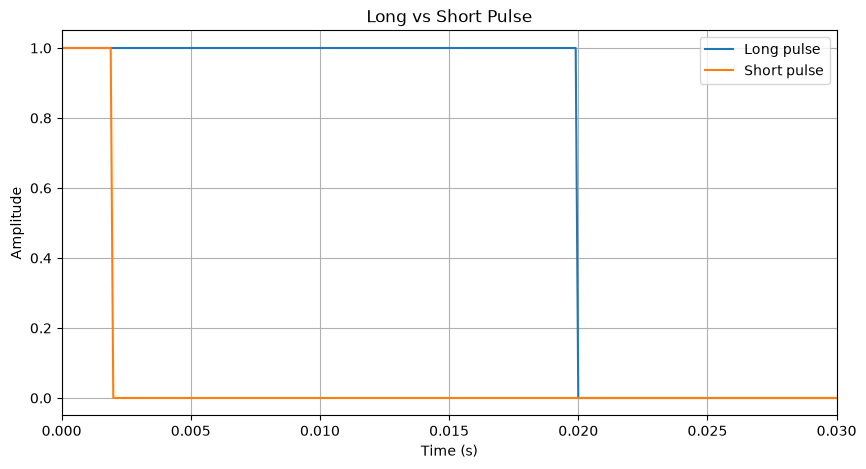

In [5]:
plt.figure(figsize=(10, 5))

plt.plot(t, long_pulse, label="Long pulse")
plt.plot(t, short_pulse, label="Short pulse")

plt.xlim(0, 0.03)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Long vs Short Pulse")
plt.legend()
plt.grid(True)

plt.show()

In [6]:
freqs = np.fft.fftfreq(N, 1/fs)

LONG = np.fft.fft(long_pulse)
SHORT = np.fft.fft(short_pulse)

positive = freqs >= 0

long_mag = np.abs(LONG[positive]) / N
short_mag = np.abs(SHORT[positive]) / N

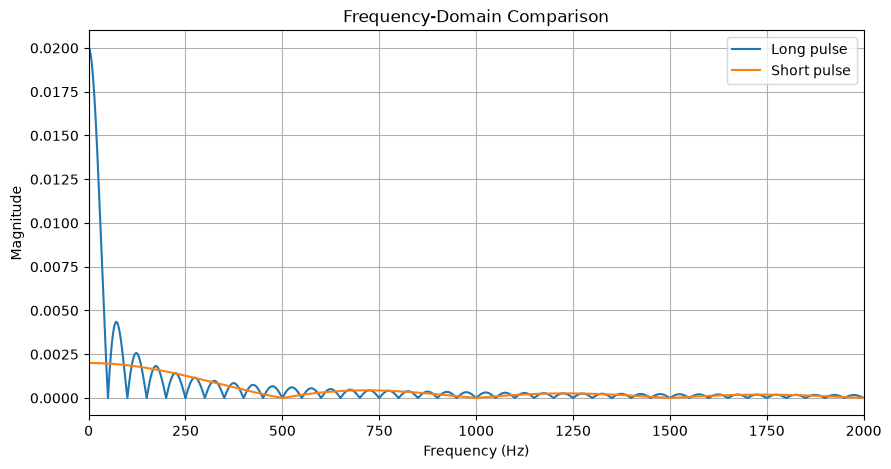

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(freqs[positive], long_mag, label="Long pulse")
plt.plot(freqs[positive], short_mag, label="Short pulse")

plt.xlim(0, 2000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency-Domain Comparison")
plt.legend()
plt.grid(True)

plt.show()

### Observation

The shorter pulse has a wider frequency spectrum, while the longer pulse has a narrower spectrum. This demonstrates the time-frequency trade-off: shorter signals occupy a wider range of frequencies.

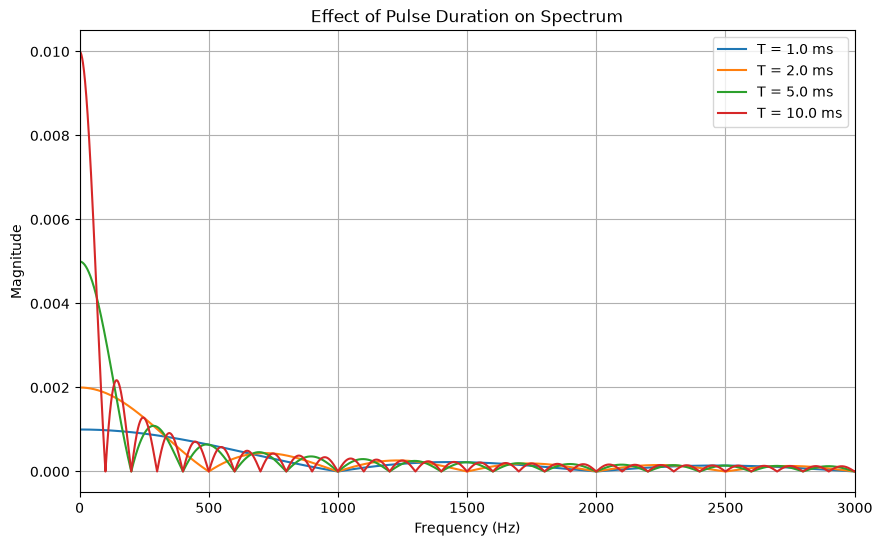

In [8]:
widths = [0.001, 0.002, 0.005, 0.01]

plt.figure(figsize=(10, 6))

for width in widths:

    pulse = np.where(t < width, 1.0, 0.0)
    spectrum = np.abs(np.fft.fft(pulse)) / N

    plt.plot(
        freqs[positive],
        spectrum[positive],
        label=f"T = {width*1000:.1f} ms"
    )

plt.xlim(0, 3000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Effect of Pulse Duration on Spectrum")
plt.legend()
plt.grid(True)

plt.show()

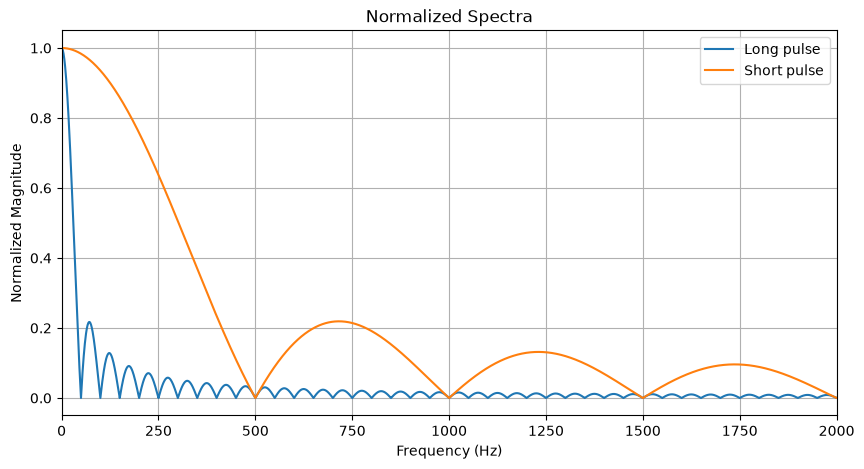

In [9]:
long_mag_norm = long_mag / np.max(long_mag)
short_mag_norm = short_mag / np.max(short_mag)

plt.figure(figsize=(10, 5))

plt.plot(
    freqs[positive],
    long_mag_norm,
    label="Long pulse"
)

plt.plot(
    freqs[positive],
    short_mag_norm,
    label="Short pulse"
)

plt.xlim(0, 2000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Magnitude")
plt.title("Normalized Spectra")
plt.legend()
plt.grid(True)

plt.show()

### Observation

As the pulse duration increases, the spectrum becomes narrower. Shorter pulses produce wider spectra. After normalization, the difference in spectral width becomes clearer, confirming the time-frequency trade-off:

$$
\Delta t \cdot \Delta f \sim \text{constant}
$$


In [10]:
fs = 10000

T1 = 0.002
T2 = 0.02

t1 = np.arange(0, T1, 1/fs)
t2 = np.arange(0, T2, 1/fs)

x1 = np.ones(len(t1))
x2 = np.ones(len(t2))

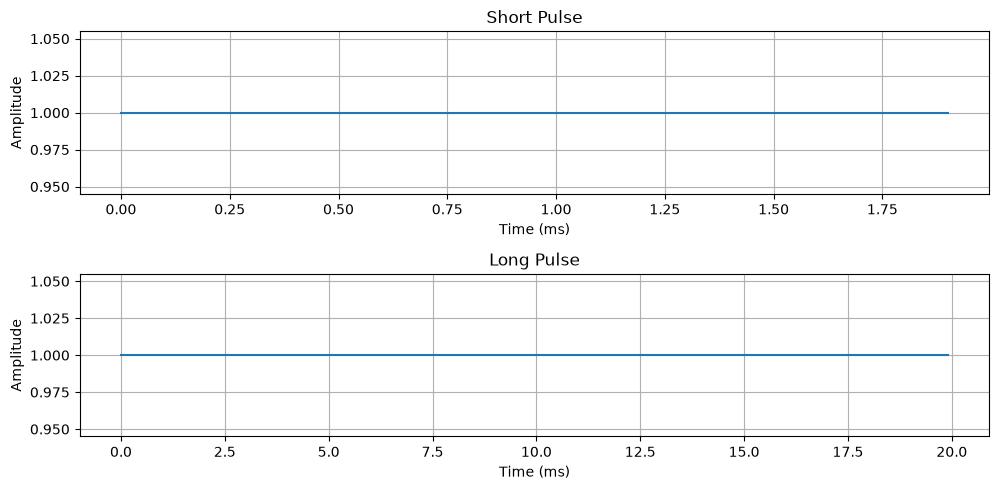

In [11]:
plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(t1 * 1000, x1)
plt.title("Short Pulse")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t2 * 1000, x2)
plt.title("Long Pulse")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
X1 = np.fft.fft(x1)
X2 = np.fft.fft(x2)

f1 = np.fft.fftfreq(len(x1), 1/fs)
f2 = np.fft.fftfreq(len(x2), 1/fs)

pos1 = f1 >= 0
pos2 = f2 >= 0

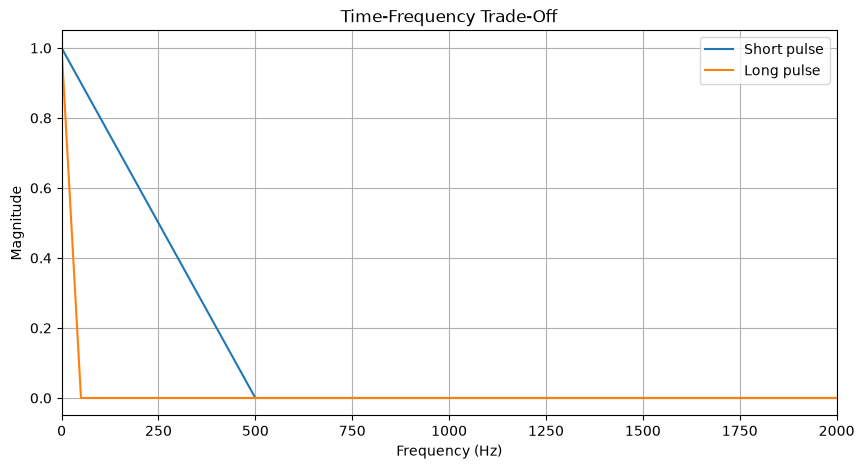

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    f1[pos1],
    np.abs(X1[pos1]) / len(x1),
    label="Short pulse"
)

plt.plot(
    f2[pos2],
    np.abs(X2[pos2]) / len(x2),
    label="Long pulse"
)

plt.xlim(0, 2000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Time-Frequency Trade-Off")
plt.legend()
plt.grid(True)

plt.show()

## Observations

- As pulse duration increases, frequency spectrum the signal covers gets smaller.

In [14]:
f0 = 500

T_short = 0.002
T_long = 0.02

t_short = np.arange(0, T_short, 1/fs)
t_long = np.arange(0, T_long, 1/fs)

short_signal = np.sin(2 * np.pi * f0 * t_short)
long_signal = np.sin(2 * np.pi * f0 * t_long)

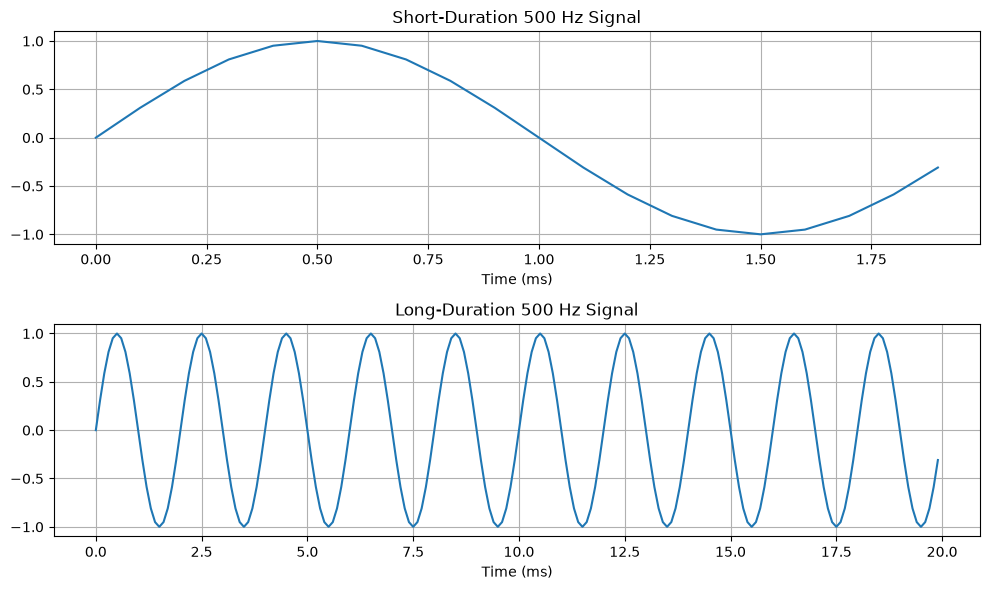

In [15]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t_short * 1000, short_signal)
plt.title("Short-Duration 500 Hz Signal")
plt.xlabel("Time (ms)")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t_long * 1000, long_signal)
plt.title("Long-Duration 500 Hz Signal")
plt.xlabel("Time (ms)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
X_short = np.fft.fft(short_signal)
X_long = np.fft.fft(long_signal)

f_short = np.fft.fftfreq(len(short_signal), 1/fs)
f_long = np.fft.fftfreq(len(long_signal), 1/fs)

pos_short = f_short >= 0
pos_long = f_long >= 0

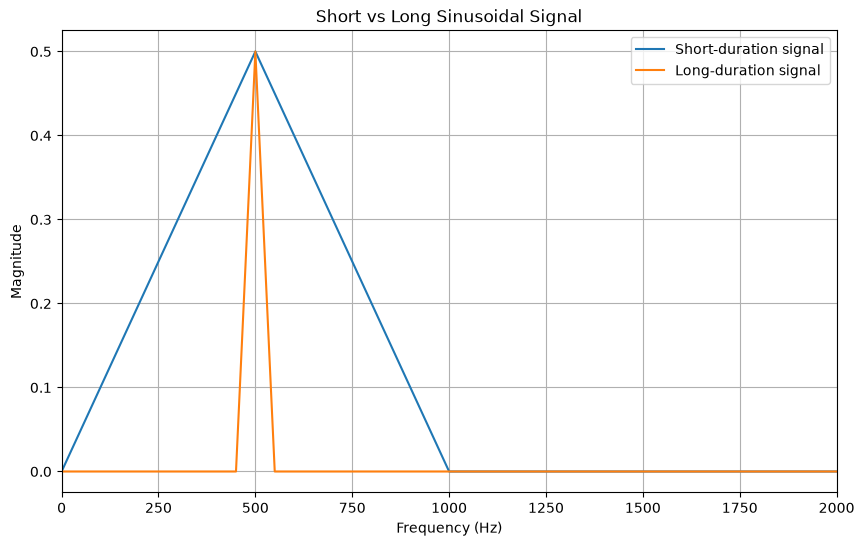

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    f_short[pos_short],
    np.abs(X_short[pos_short]) / len(short_signal),
    label="Short-duration signal"
)

plt.plot(
    f_long[pos_long],
    np.abs(X_long[pos_long]) / len(long_signal),
    label="Long-duration signal"
)

plt.xlim(0, 2000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Short vs Long Sinusoidal Signal")
plt.legend()
plt.grid(True)

plt.show()

## Observations

- The longer a sinusoidal signal is transmitted, the narrower its frequency spectrum becomes.

## Key Takeaways

* Bandwidth describes how widely a signal's energy is spread across the frequency domain.

* A shorter-duration signal has a wider frequency spectrum, while a longer-duration signal has a narrower spectrum.

* The signal's spectral peak and spectral width are different properties. A longer pulse can have a higher peak while still having a narrower spectrum.

* Normalizing the spectra makes the difference in spectral width easier to compare.

* The time-frequency trade-off can be summarized as:

$$
\Delta t \cdot \Delta f \sim \text{constant}
$$

* This relationship means that improving time localization generally comes at the cost of wider frequency content, and vice versa.

* This trade-off is important in systems such as radar and communications, where signal duration and bandwidth affect system performance.


## Next Step

Next, we will move from signal and system fundamentals toward digital communication fundamentals.